# CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026

## Project Checkpoint 1: Dataset Comparison, Selection, and EDA

### (A) Identification of Candidate Datasets

**Motivation: Why Travel Data?**

As a grad student trying to plan my spring break trip, I recently found myself jumping between Google Flights, airline websites, and random Reddit threads trying to figure out:

- When is the cheapest time to fly?
- Are certain routes consistently overpriced?
- Is there a 'hidden' structure in flight networks?

At one point I noticed that flights from smaller airports sometimes had surprisingly high fares compared to longer routes. That made me curious: is there an underlying network or pricing pattern that explains this?

Since I am already interested in optimizing travel plans (and as someone who loves trips - beaches, sunsets, spontaneous getaways), I decided to explore travel-related datasets for my this project.

**Candidate Dataset 1**

**Expedia Hotel Recommendations Dataset**

Source:
Kaggle - Expedia Hotel Recommendations Competition
https://www.kaggle.com/competitions/expedia-hotel-recommendations/data

Course Topic Alignment:

- Frequent Itemsets / Association Rules: User behavior patterns in booking combinations
- Clustering: Customer segmentation
- Classification: Predicting hotel clusters

Potential Beyond-Course Techniques:

- Sequential pattern mining (booking sequences over time)
- Gradient boosting / XGBoost ranking models
- Collaborative filtering (matrix factorization)
- Context-aware recommendation models

Dataset Size and Structure:

- ~300 million rows (full dataset)
- Tabular dataset
- Each row = search event or booking event
- Very large-scale; may require sampling

Data Types:
User IDs,
Search timestamp, Destination ID, Hotel cluster (100 predefined clusters), Booking flag (0/1), Numeric features (stay length, adults, children), Categorical variables (country, market, channel)

Target Variable(s):
- hotel_cluster (multiclass classification)
- is_booking (binary)

Licensing / Usage Constraints:
- Kaggle competition dataset
- Allowed for research and educational purposes
- Must follow Kaggle competition terms

**Candidate Dataset 2**

**Traveler Trip Data Dataset**

Source:
Kaggle – Traveler Trip Data
https://www.kaggle.com/datasets/rkiattisak/traveler-trip-data/data

Course Topic Alignment:

- Clustering (grouping traveler types)
- Frequent itemsets (co-occurring destinations)
- Anomaly detection (unusual spending or duration patterns)

Potential Beyond-Course Techniques:

- Time-series modeling
- Sequential itinerary mining
- Topic modeling on travel descriptions (if available)

Dataset Size and Structure:

- Smaller dataset (manageable for local analysis)
- Structured tabular data
- Each row = individual trip

Data Types:
Traveler ID, Destination, Trip duration, Spending amount, Travel purpose, Demographics

Target Variable(s):
No explicit supervised target. Suitable for unsupervised analysis

Licensing / Usage Constraints:
- Public Kaggle dataset
- Educational use permitted

**Candidate Dataset 3 (Final Choice)**

**US Airline Flight Routes and Fares (1993–2024)**

Source:
Kaggle – US Airline Flight Routes and Fares
https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024

Course Topic Alignment:

- Graph Mining: Airports as nodes, Routes as edges, Centrality measures, Community detection
- Clustering: Grouping routes by fare patterns
- Anomaly Detection: Detecting unusually high-priced routes

Potential Beyond-Course Techniques:

- Node embeddings (Node2Vec / DeepWalk)
- Graph Neural Networks (GNNs)
- Temporal network analysis
- Dynamic pricing modeling
- Causal inference on route competition

Dataset Size and Structure:

- Covers 1993–2024
- Millions of route-fare observations
- Tabular format
- Each row represents a route-year-quarter combination (depending on dataset granularity)
- This dataset has : Network structure (routes), Temporal dimension (years), Economic variable (fares)

This makes it rich for multi-dimensional analysis.

Data Types:
Origin airport (categorical), Destination airport (categorical), Year / Quarter, Fare price (numeric), Passenger counts, Market share, Distance

Target Variable(s):
- No single mandatory target
- Possible supervised targets: Fare prediction (regression), High-price vs low-price classification
- Strong support for unsupervised graph analysis-

Licensing / Usage Constraints:
- Public Kaggle dataset
- Educational/research use permitted
- Must follow Kaggle dataset license terms

### (B) Comparative Analysis of Datasets

After identifying three travel-related datasets, I compared them based on their data properties, feasibility, supported techniques (both course and beyond-course), and ethical/bias considerations. Since I am genuinely interested in travel patterns and pricing (especially while planning my own trips), I wanted to make sure the dataset I choose is not only interesting but also technically strong for this course.

Below is a structured comparison.


| Dimension                                                | Expedia Hotel Recommendations                                                                                                                                                                                                           | Traveler Trip Data                                                                                                                                                                        | US Airline Flight Routes & Fares (1993–2024)                                                                                                                                                                                                                                     |
| -------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Supported Data Mining Tasks (Course + Beyond Course)** | **Course:** Classification (predict hotel cluster), clustering, possibly association rules on search behavior. <br> **Beyond-course:** Recommender systems (collaborative filtering), ranking models, sequential pattern mining.        | **Course:** Clustering traveler segments, anomaly detection (unusual spend/duration), basic association analysis. <br> **Beyond-course:** Sequential trip modeling, time-series analysis. | **Course:** Graph mining (airports as nodes, routes as edges), centrality measures, community detection, clustering routes by fare, anomaly detection (price outliers). <br> **Beyond-course:** Node embeddings (Node2Vec), temporal network analysis, dynamic pricing modeling. |
| **Data Quality Issues**                                  | Very large log-style dataset. Likely missing values in user or destination fields. Click vs booking labels may introduce noise (many clicks do not represent real intent). Also requires careful time-based splitting to avoid leakage. | Smaller and cleaner, but possibly curated. May have missing demographic information, inconsistent formatting of destinations, or unrealistic distributions if synthetic.                  | Structured dataset but spans many years (1993–2024), so inflation and era effects must be handled. Possible duplicate routes across time. Need to normalize fares for fair comparison across decades.                                                                            |
| **Algorithmic Feasibility**                              | Very large dataset. Full processing may require sampling. Algorithms like Apriori or complex models may be computationally expensive without careful optimization.                                                                      | Very manageable size. All course algorithms can run comfortably on a laptop. Good for experimentation.                                                                                    | Manageable size. Graph construction and centrality analysis feasible without Spark. Temporal and embedding-based methods also computationally realistic.                                                                                                                         |
| **Bias Considerations**                                  | Platform bias: only Expedia users. Exposure bias (what is shown influences what is booked). May overrepresent certain income groups or regions.                                                                                         | Likely sampling bias depending on how data was collected. May not represent broader travel population.                                                                                    | Coverage bias: limited to US routes. Major airports likely dominate network structure. Fare differences may reflect competition levels or market power rather than simple pricing patterns.                                                                                      |
| **Ethical Considerations**                               | User behavior logs may reflect sensitive preferences (even if anonymized). Risk of reinforcing pricing or recommendation inequality if misused.                                                                                         | Low privacy risk if anonymized. Risk lies in overgeneralizing findings from possibly limited dataset.                                                                                     | Low privacy concerns since data is route-level and aggregated. Need to avoid misinterpreting pricing patterns without considering economic factors (e.g., competition, demand).                                                                                                  |


**Comparative Reflection**

Expedia Dataset:

This dataset is very realistic and industry-grade. It strongly supports supervised learning and recommendation tasks, which are exciting. However, it is extremely large and would require careful sampling and heavy preprocessing. I would spend a significant portion of time handling scale rather than exploring insights. While it is powerful, it may be overwhelming for this semester project.

Traveler Trip Dataset:

This dataset is easy to manage and clean. It is good for clustering and anomaly detection. However, it feels somewhat limited in depth and realism. It does not naturally support graph-based analysis or large-scale economic trends. It may be too simple for exploring advanced external techniques.

US Airline Flight Routes & Fares Dataset:

This dataset offers a strong balance between complexity and feasibility. It naturally supports graph mining (airports and routes), which directly aligns with course topics. At the same time, it allows exploration of beyond-course techniques like node embeddings and temporal network analysis.

It also includes a time dimension spanning 30+ years, which opens interesting questions about fare evolution, network growth, and route competition. From a computational standpoint, it is large enough to be meaningful but small enough to handle on a personal machine.

### (C) Dataset Selection

**Selected Dataset**:
US Airline Flight Routes and Fares (1993–2024)


**Why I Selected This Dataset**

After comparing all three options, I chose the US Airline Flight Routes and Fares dataset because it offers the best balance between course alignment, analytical depth, feasibility, and personal interest.

1. Strong Course Alignment

This dataset naturally supports graph mining, which is a core topic in this course.
- Airports can be modeled as nodes
- Routes as edges
- Fares as edge weights

This allows me to apply centrality measures, community detection, clustering, and anomaly detection. Compared to the other datasets, this one has a clear network structure, which makes it more suitable for graph-based analysis.


2. Opportunity for Beyond-Course Techniques

Beyond course methods, this dataset enables:

- Node embeddings (e.g., Node2Vec)
- Temporal network analysis (since it spans 1993–2024)
- Fare prediction or trend modeling

The long time span adds a dynamic aspect, allowing me to explore how route connectivity and pricing evolve over time.

3. Feasibility

The Expedia dataset is extremely large and would require heavy sampling and preprocessing. The Traveler Trip dataset is manageable but relatively limited in structure and depth.

- The airline dataset is a strong middle ground:
- Large enough to be meaningful
- Structured and manageable on a personal machine
- Rich enough to support multiple techniques


4. Personal Motivation

I was motivated to explore travel data while planning upcoming trips. I often notice that some routes seem unusually expensive, and some airports appear much more connected than others.

This dataset allows me to explore questions like:
- Do highly connected airports have different pricing patterns?
- Are certain routes consistently overpriced relative to distance?
- How has the airline network evolved over time?

This makes the project both academically meaningful and personally interesting.

**Trade-Offs**

- No user-level booking behavior
- Limited to US routes
- Does not explicitly include economic factors like fuel prices or competition levels

Despite these limitations, it strongly supports both course and beyond-course techniques while remaining computationally feasible.

**Final Justification**

The US Airline Flight Routes and Fares dataset stands out because it:
- Directly supports graph mining (course-aligned)
- Allows advanced network-based extensions (beyond-course)
- Includes a temporal component
- Is computationally manageable
- Aligns with my genuine interest in travel and pricing patterns

For these reasons, I selected this dataset for my project.

### (D) Exploratory Data Analysis



In [78]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [79]:
import pandas as pd

file_path = '/content/drive/My Drive/Sem4/Data Mining/project/airline_data.csv'
df = pd.read_csv(file_path, low_memory=False)

**Data Exploration**

In [80]:
df.head()

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  object 
 11  nsmiles         245955 non-null  int64  
 12  passengers      245955 non-null  int64  
 13  fare            245955 non-null  float64
 14  carrier_lg      244415 non-null  object 
 15  large_ms        244415 non-null  float64
 16  fare_lg         244415 non-null  float64
 17  carrier_lo

In [82]:
df.describe()

,Year,quarter,citymarketid_1,citymarketid_2,airportid_1,airportid_2,nsmiles,passengers,fare,large_ms,fare_lg,lf_ms,fare_low
count,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,245955.000000,244415.000000,244415.000000,244343.000000,244343.000000
mean,2008.524124,2.479153,31556.430201,32180.117086,12437.099986,13249.889525,1189.812319,299.476795,218.979587,0.665252,218.710963,0.450438,190.675939
std,8.703364,1.122149,1089.872880,1232.464184,1431.665257,1425.810159,703.143472,511.389486,82.372486,0.224635,84.674363,0.332669,73.577694
min,1993.000000,1.000000,30135.000000,30189.000000,10135.000000,10466.000000,109.000000,0.000000,50.000000,0.003800,50.000000,0.010000,50.000000
25%,2001.000000,1.000000,30721.000000,30994.000000,11193.000000,12197.000000,626.000000,21.000000,164.620000,0.480000,161.500000,0.158000,140.060000
50%,2008.000000,2.000000,31423.000000,32211.000000,12266.000000,13303.000000,1023.000000,113.000000,209.320000,0.652400,208.030000,0.360000,181.630000
75%,2016.000000,3.000000,32467.000000,33192.000000,13487.000000,14679.000000,1736.000000,339.000000,262.890000,0.871900,263.640000,0.750000,230.040000
max,2024.000000,4.000000,35412.000000,35628.000000,16440.000000,15919.000000,2724.000000,8301.000000,3377.000000,1.000000,2725.600000,1.000000,2725.600000


In [83]:
print("--Column Names:--")
df.columns

--Column Names:--


Index(['tbl', 'Year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1',
       'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2',
       'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg',
       'carrier_low', 'lf_ms', 'fare_low', 'Geocoded_City1', 'Geocoded_City2',
       'tbl1apk'],
      dtype='object')

In [84]:
print("--Shape of the Data:--")
df.shape

--Shape of the Data:--


(245955, 23)

In [85]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f'Duplicates: {duplicates}')

Duplicates: 0


**Data Cleaning**

In [86]:
df_raw = df.copy()

# Standardize column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)
df.columns

Index(['tbl', 'year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1',
       'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2',
       'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg',
       'carrier_low', 'lf_ms', 'fare_low', 'geocoded_city1', 'geocoded_city2',
       'tbl1apk'],
      dtype='object')

In [87]:
missing_values = df.isnull().sum()
missing_values

,0
tbl,0
year,0
quarter,0
citymarketid_1,0
citymarketid_2,0
city1,0
city2,0
airportid_1,0
airportid_2,0
airport_1,0


In [88]:
# Drop rows with any missing values
df_cleaned = df.dropna()

# Drop columns with any missing values
df_cleaned_columns = df.dropna(axis=1)

print(df_cleaned.shape)
print(df_cleaned_columns.shape)


(205189, 23)
(245955, 15)


In [92]:
# Remove self-routes
df = df[df["city1"] != df["city2"]]

# Remove invalid fares
df = df[df["fare"] > 0]

# Validate market share columns (should be between 0 and 1)
df = df[(df["large_ms"] >= 0) & (df["large_ms"] <= 1)]
df = df[(df["lf_ms"] >= 0) & (df["lf_ms"] <= 1)]

I assume market share values are proportions bounded between 0 and 1. Any values outside this range are treated as data inconsistencies.

In [95]:
# Create Route Column
df["route"] = df.apply(
    lambda row: "-".join(sorted([row["city1"], row["city2"]])),
    axis=1
)

df["route"].head()

,route
0,"Allentown/Bethlehem/Easton, PA-Tampa, FL (Metr..."
1,"Allentown/Bethlehem/Easton, PA-Tampa, FL (Metr..."
2,"Albuquerque, NM-Dallas/Fort Worth, TX"
3,"Albuquerque, NM-Dallas/Fort Worth, TX"
4,"Albuquerque, NM-Phoenix, AZ"


I assume that routes are undirected, meaning that City A → City B and City B → City A represent the same market. This simplifies the network analysis and allows modeling routes as undirected edges.

In [97]:
# Handle Outliers

# Airline fares are naturally skewed.
# Instead of deleting, flag them
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

df["fare_outlier"] = df["fare"] > upper
df["fare_outlier"].mean()

np.float64(0.01844947471382442)

  I assume that extreme fares may reflect genuine market behavior (e.g., monopoly routes or peak demand), so I flag them rather than remove them.

In [115]:
# Data validation tests (sanity checks)
assert (df["fare"] > 0).all(), "Found non-positive fares"
assert (df["city1"] != df["city2"]).all(), "Found self-routes"

assert df["large_ms"].between(0, 1).all(), "large_ms out of [0,1]"
assert df["lf_ms"].between(0, 1).all(), "lf_ms out of [0,1]"

assert df["route"].notna().all(), "Missing route values"
assert df["year"].notna().all(), "Missing year values"

**Exploratory Data Analysis**

In [99]:
import warnings
warnings.filterwarnings('ignore')

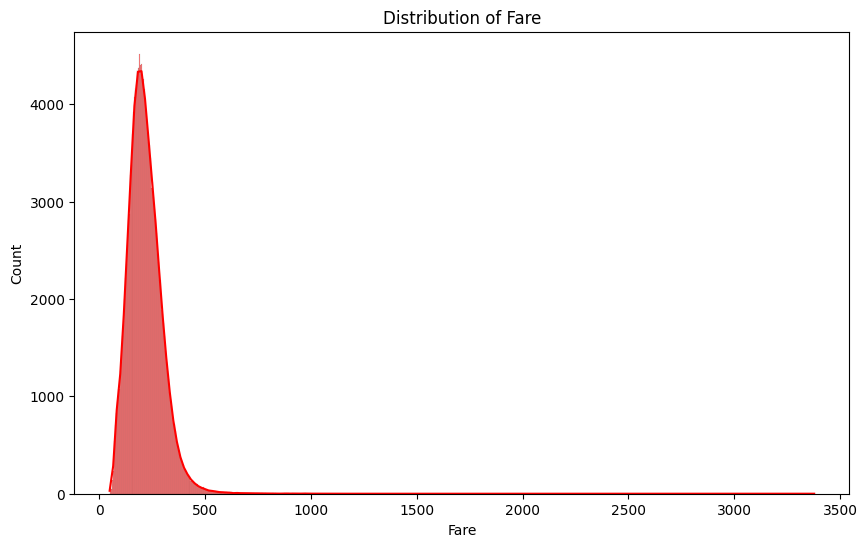

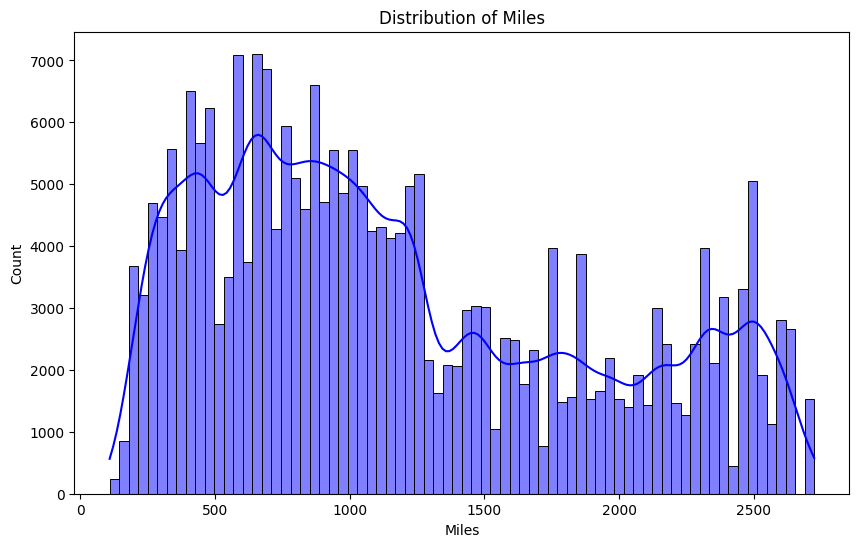

In [100]:
#Distribution of Fare and nsmiles

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of fare
plt.figure(figsize=(10, 6))
sns.histplot(df['fare'], kde=True, color='red')
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

# Distribution of nsmiles
plt.figure(figsize=(10, 6))
sns.histplot(df['nsmiles'], kde=True, color='blue')
plt.title('Distribution of Miles')
plt.xlabel('Miles')
plt.ylabel('Count')
plt.show()

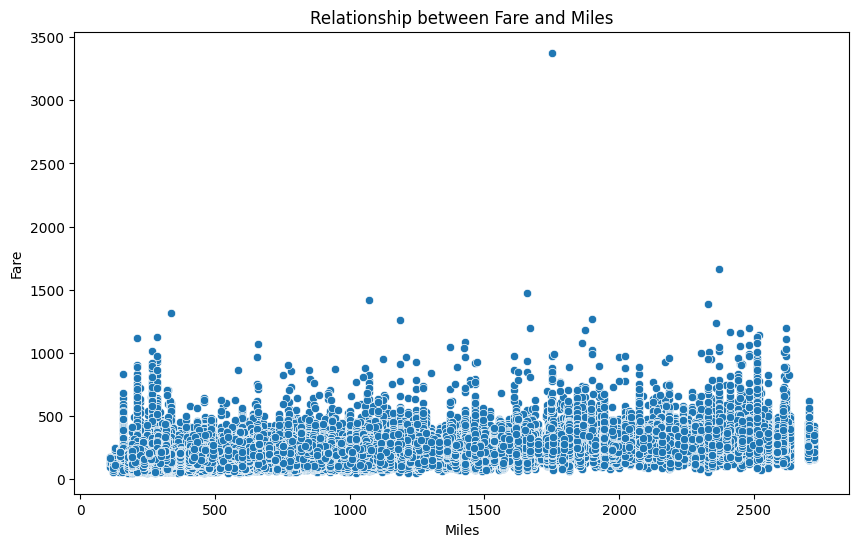

In [101]:
# Relation between Fare and nsmiles

plt.figure(figsize=(10, 6))
sns.scatterplot(x='nsmiles', y='fare', data=df)
plt.title('Relationship between Fare and Miles')
plt.xlabel('Miles')
plt.ylabel('Fare')
plt.show()

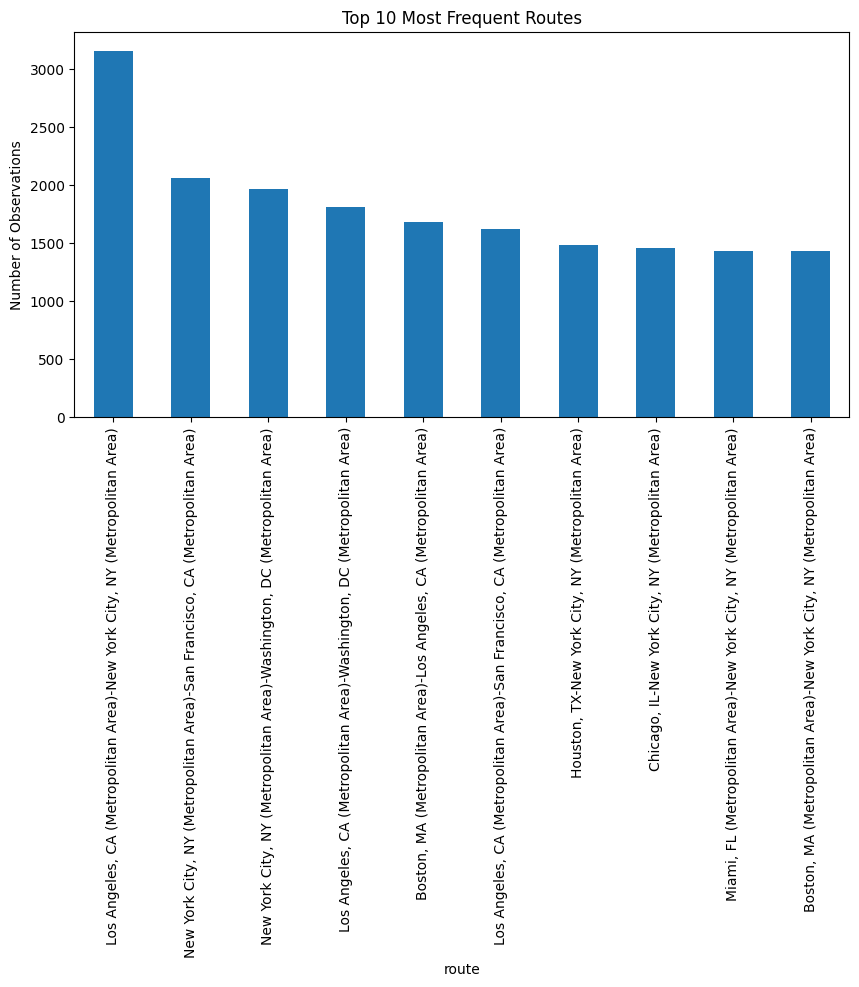

In [102]:
#Most commone routes
top_routes = df["route"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind="bar")
plt.title("Top 10 Most Frequent Routes")
plt.ylabel("Number of Observations")
plt.show()

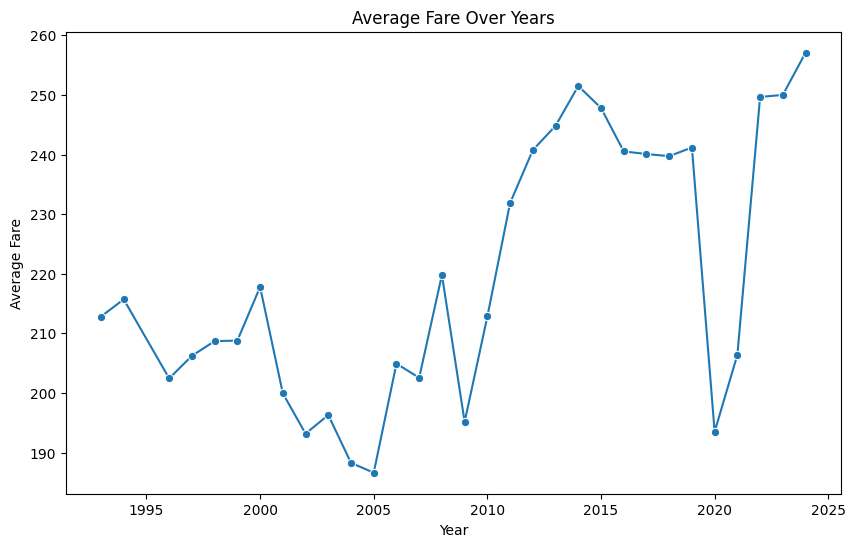

In [104]:
# Temporal Trends (Average Fare Over Years)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='fare', data=df.groupby('year')['fare'].mean().reset_index(), marker='o')
plt.title('Average Fare Over Years')
plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.show()

Fares show noticeable variation across years. However, inflation effects must be considered when interpreting long-term trends. Temporal variation suggests potential for dynamic network analysis beyond static graph methods.

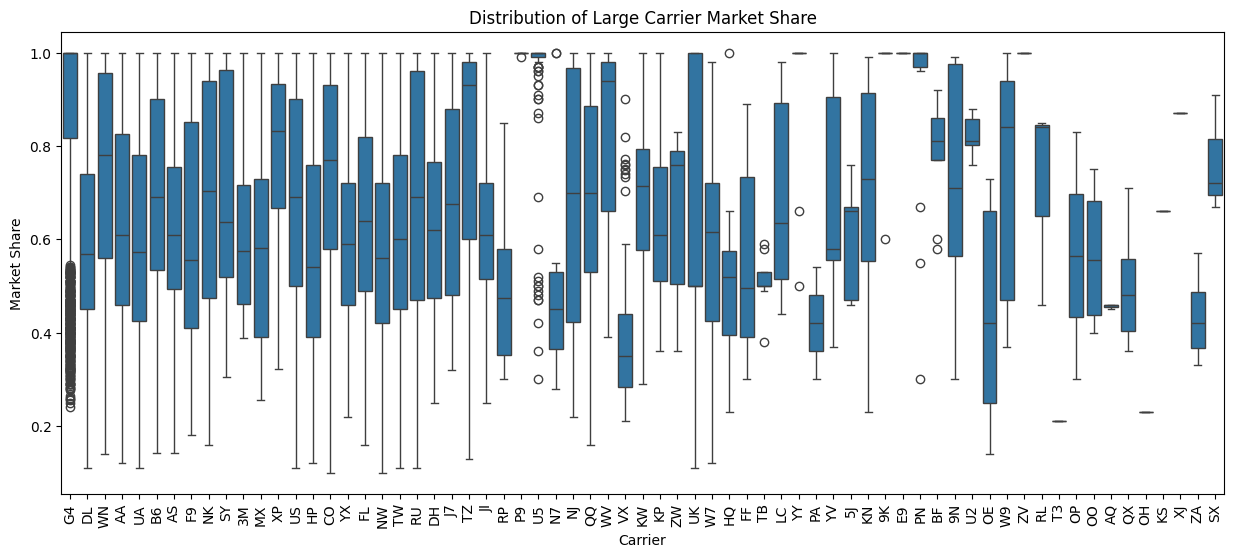

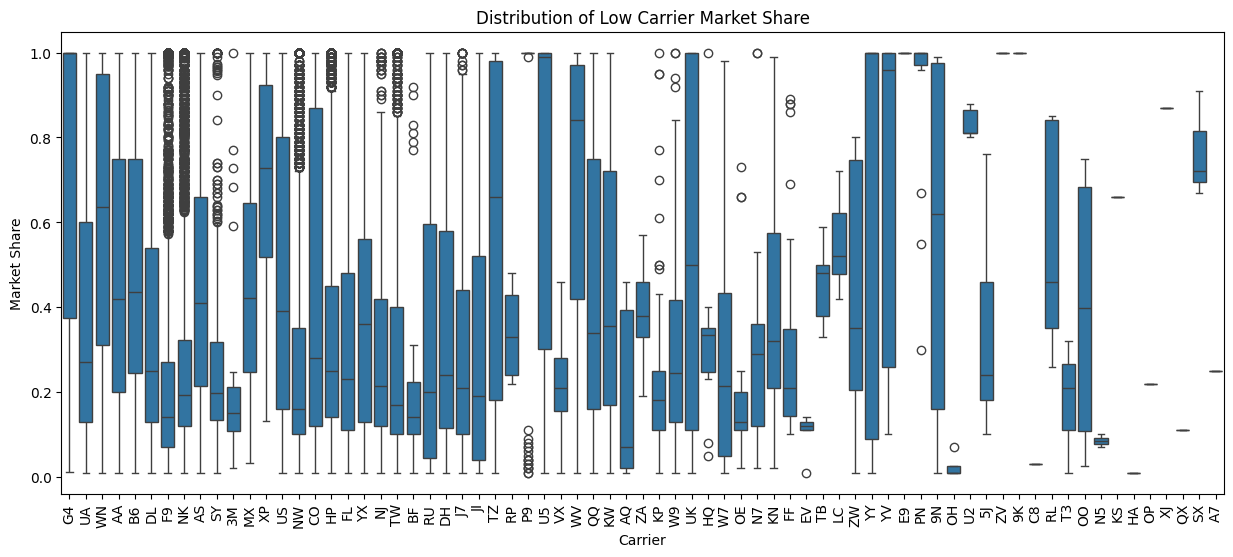

In [105]:
# Distribution of carrier_lg and carrier_low market shares?
plt.figure(figsize=(15, 6))
sns.boxplot(x='carrier_lg', y='large_ms', data=df)
plt.title('Distribution of Large Carrier Market Share')
plt.xlabel('Carrier')
plt.xticks(rotation=90)
plt.ylabel('Market Share')
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(x='carrier_low', y='lf_ms', data=df)
plt.title('Distribution of Low Carrier Market Share')
plt.xlabel('Carrier')
plt.xticks(rotation=90)
plt.ylabel('Market Share')
plt.show()

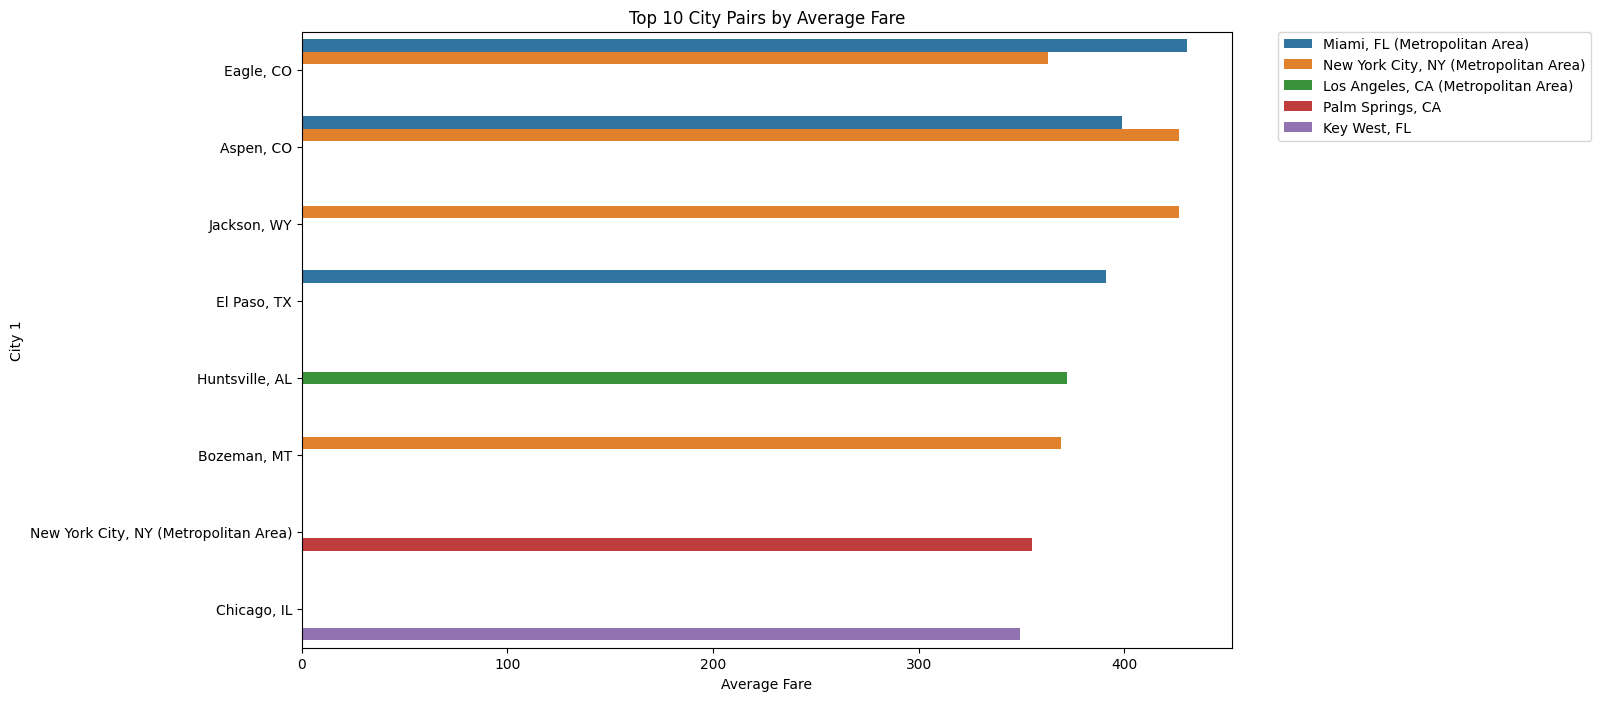

In [106]:
# City1 - city2 combinations having the highest average fare

# Calculate the average fare for each city pair
city_pairs_fare = df.groupby(['city1', 'city2'])['fare'].mean().reset_index()

# Sort by the highest average fare and take the top 10
top_city_pairs_fare = city_pairs_fare.nlargest(10, 'fare')

plt.figure(figsize=(12, 8))
sns.barplot(x='fare', y='city1', hue='city2', data=top_city_pairs_fare)
plt.title('Top 10 City Pairs by Average Fare')
plt.xlabel('Average Fare')
plt.ylabel('City 1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

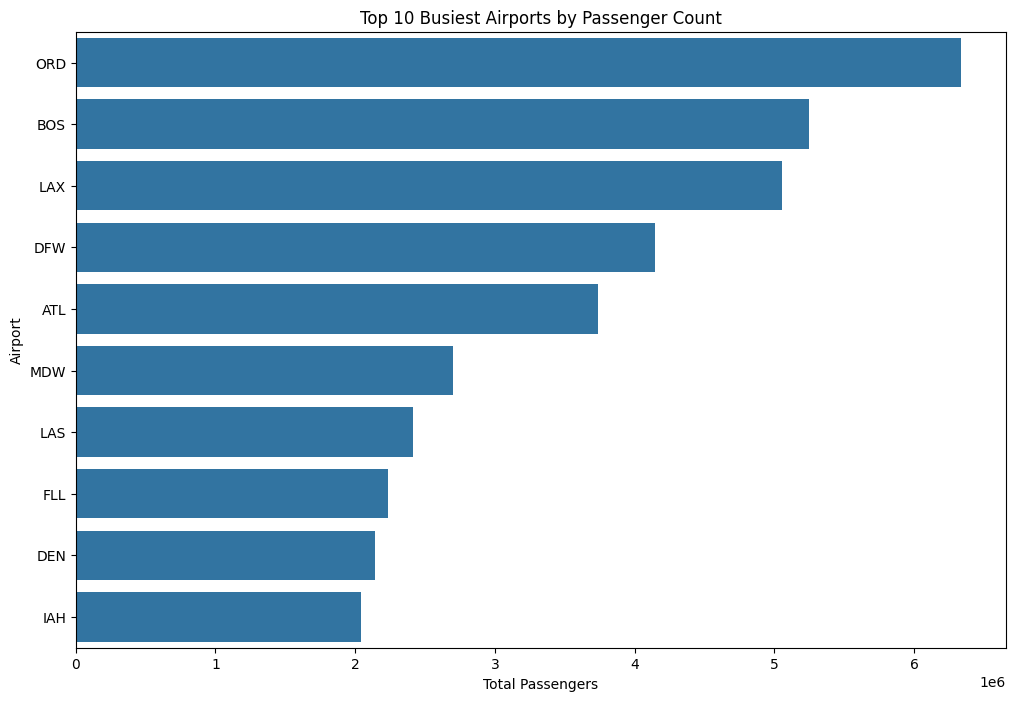

In [107]:
# Busiest airports in terms of passenger count

# Group by airport_1 and airport_2 separately and sum passengers
airport1_passengers = df.groupby('airport_1')['passengers'].sum().reset_index()
airport2_passengers = df.groupby('airport_2')['passengers'].sum().reset_index()

# Concatenate the results
busiest_airports = pd.concat([airport1_passengers, airport2_passengers], ignore_index=True)
busiest_airports = busiest_airports.groupby('airport_1')['passengers'].sum().reset_index()

# Top 10 busiest airports
top_airports = busiest_airports.nlargest(10, 'passengers')

plt.figure(figsize=(12, 8))
sns.barplot(x='passengers', y='airport_1', data=top_airports)
plt.title('Top 10 Busiest Airports by Passenger Count')
plt.xlabel('Total Passengers')
plt.ylabel('Airport')
plt.show()

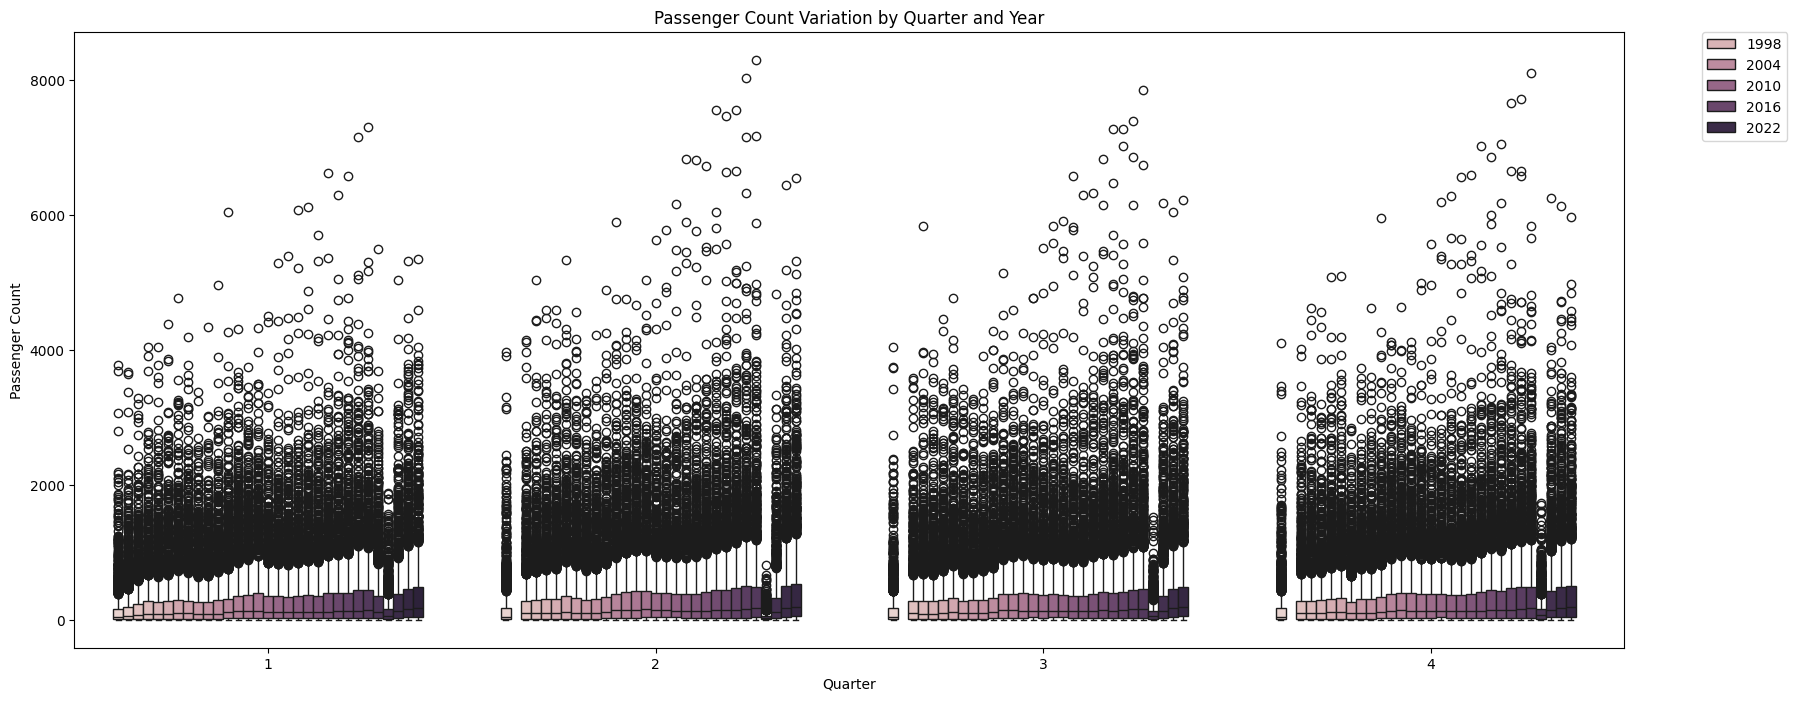

In [113]:
# Passenger count varying by quarter and year
plt.figure(figsize=(20, 8))
sns.boxplot(x='quarter', y='passengers', hue='year', data=df)
plt.title('Passenger Count Variation by Quarter and Year')
plt.xlabel('Quarter')
plt.ylabel('Passenger Count')
plt.legend(title='Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

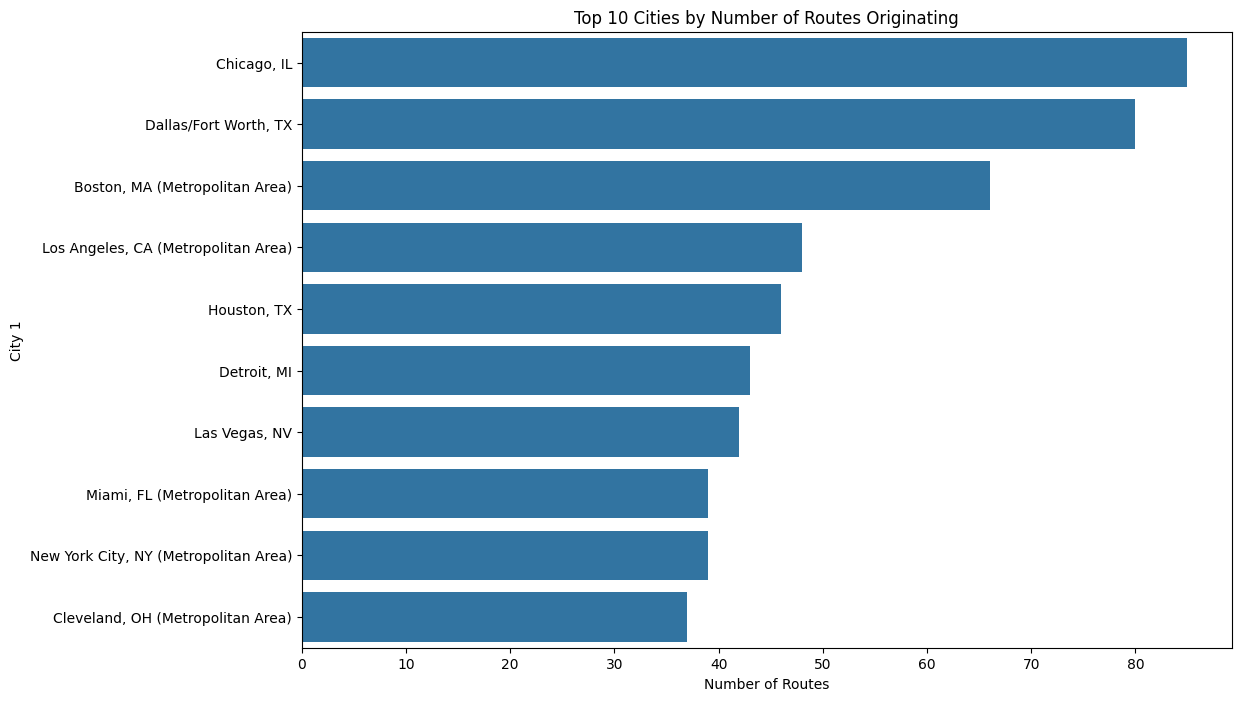

In [108]:
#Cities that have the most routes originating from it

# Count the number of unique city2 for each city1
city_routes = df.groupby('city1')['city2'].nunique().reset_index().sort_values(by='city2', ascending=False)

# Top 10 cities with the most routes
top_city_routes = city_routes.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='city2', y='city1', data=top_city_routes)
plt.title('Top 10 Cities by Number of Routes Originating')
plt.xlabel('Number of Routes')
plt.ylabel('City 1')
plt.show()

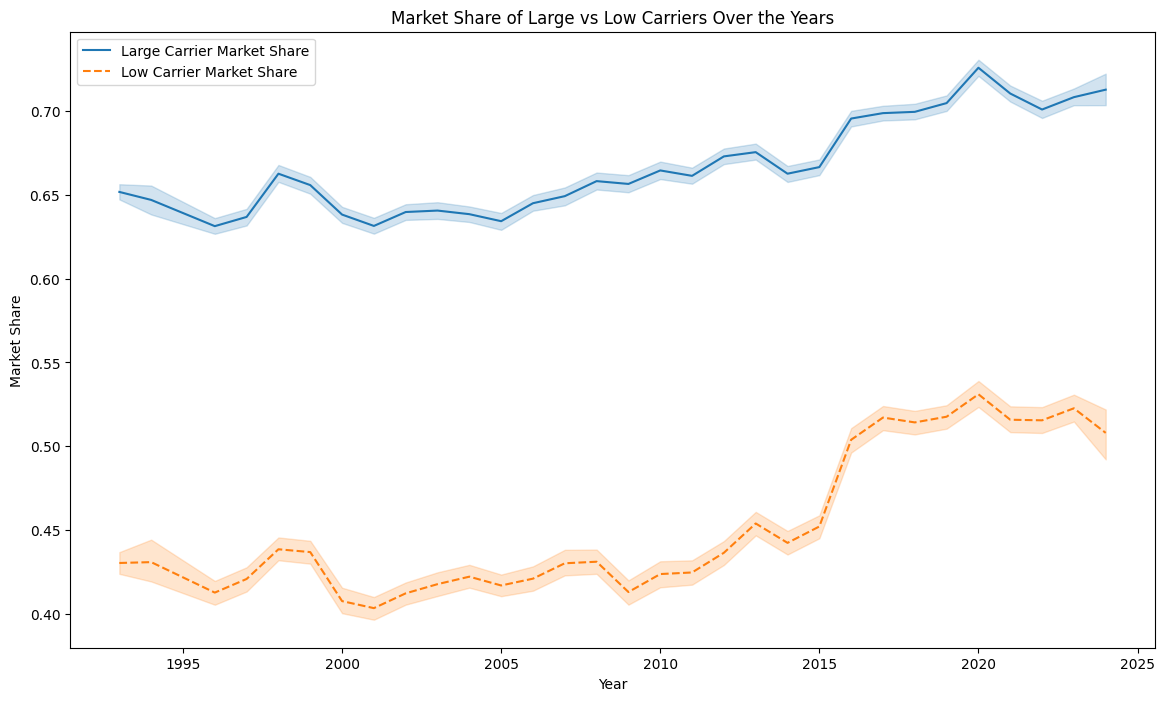

In [110]:
# market share (large_ms vs lf_ms) varying across different year
plt.figure(figsize=(14, 8))
sns.lineplot(x='year', y='large_ms', data=df, label='Large Carrier Market Share')
sns.lineplot(x='year', y='lf_ms', data=df, label='Low Carrier Market Share', linestyle='--')
plt.title('Market Share of Large vs Low Carriers Over the Years')
plt.xlabel('Year')
plt.ylabel('Market Share')
plt.legend()
plt.show()

In [114]:
# Network Sparsity
num_nodes = len(set(df["city1"]).union(set(df["city2"])))
num_edges = df["route"].nunique()

density = num_edges / (num_nodes * (num_nodes - 1) / 2)

print("Number of Nodes:", num_nodes)
print("Number of Unique Routes:", num_edges)
print("Approximate Network Density:", density)


Number of Nodes: 171
Number of Unique Routes: 1266
Approximate Network Density: 0.08710010319917441


**Overall EDA Summary**

The exploratory data analysis reveals that the U.S. airline network exhibits strong structural and economic heterogeneity. Fare distributions are right-skewed, indicating the presence of high-priced routes alongside a large number of moderately priced connections. While fares generally increase with distance (nsmiles), significant variability exists, suggesting that factors beyond distance influence pricing. The network structure appears sparse but centralized, with certain airports and routes dominating passenger traffic and connectivity. Temporal analysis shows fluctuations in fares and market share across years, highlighting evolving competitive dynamics between large and low-cost carriers. Overall, the dataset demonstrates meaningful structural, temporal, and pricing patterns, making it suitable for both graph-based and advanced modeling techniques.

**Initial Observations Motivating External Techniques**

The exploratory analysis reveals that the airline network is sparse but highly centralized, with a small number of cities acting as major hubs. This suggests that simple centrality measures may not fully capture structural similarities between airports. Therefore, node embedding techniques (e.g., Node2Vec) could help uncover deeper relational patterns in the network.

Additionally, while fares generally increase with distance, there is significant variability for routes with similar miles traveled. This indicates that pricing is influenced by factors beyond distance alone, motivating the use of embedding-based modeling or anomaly detection methods to better understand structural pricing effects.

Finally, noticeable variation in fares and market share over time suggests evolving competition dynamics. This motivates exploring temporal network analysis to study how connectivity and pricing patterns change across years.

### (E) Initial Insights and Direction

**Key Observations from EDA**

- The airline network is sparse, but a small number of airports dominate connectivity and passenger traffic.
- Fare distribution is right-skewed, with some routes consistently priced much higher than others.
- Fare is positively related to distance, but there is high variability for similar distances.
- Market share of large vs low-cost carriers changes over time, suggesting evolving competition.
- Certain routes show high fare variability across years.


**Hypotheses**

- Based on these observations, I hypothesize:
- Highly connected hub airports may exhibit different pricing behavior compared to less connected airports.
- Fare differences are influenced not only by distance but also by structural position in the network (e.g., monopoly vs competitive routes).
- Temporal changes in market share may be associated with fare volatility or pricing stability.
- Routes embedded within dense sub-networks may behave differently from isolated routes.


**Potential Research Questions (RQs)**

- Structural Pricing Question: Do airports with higher centrality (degree or betweenness) have systematically different average fares?
- Network Embedding Question (Beyond-Course): Can node embeddings reveal clusters of structurally similar airports that traditional centrality measures fail to detect?
- Competition and Pricing Question: Is fare variability associated with shifts in market share between large and low-cost carriers?
- Temporal Dynamics Question: How does the airline network structure evolve over time, and does this evolution relate to pricing patterns?


**Direction of the Project**

Moving forward, I plan to:

- Apply graph mining techniques (centrality and community detection) to understand structural influence.
- Extend the analysis using node embeddings to capture latent relationships between airports.
- Incorporate temporal analysis to study changes in connectivity and fare behavior over time.
- These directions build directly from the patterns observed during EDA and align with both course and beyond-course techniques.

On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- Kaggle - Expedia Hotel Recommendations Competition
https://www.kaggle.com/competitions/expedia-hotel-recommendations/data
- Kaggle – Traveler Trip Data
https://www.kaggle.com/datasets/rkiattisak/traveler-trip-data/data
- Kaggle – US Airline Flight Routes and Fares
https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024

3. AI Tools:
- ChatGPT: used for outlining sections, understanding the data, cleaning, EDA, refining wording for the answers, and suggesting cleaning/EDA checks. Also used it to compare my 3 chosen datasets